In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os

In [7]:
raw_data="../../data/species"

!ls $raw_data
!ls ../training_data/geneid-parameter-files/parameter_files/*.param

Babesia_duncani_323732
Chaetoceros_neogracilis_240364
Chlamydomonas_reinhardtii_3055
Cladocopium_goreaui_2562237
Conticribra_weissflogii_1577725
Cryptosporidium_parvum_Iowa_II_353152
Cyanidiococcus_yangmingshanensis_2690220
Cyanidioschyzon_merolae_strain_10d_280699
Cyanidioschyzon_merolae_strain_10D_280699
Cyanidium_caldarium_2771
Cylindrotheca_closterium_2856
Dunaliella_salina_3046
Durusdinium_trenchii_1381693
Eimeria_necatrix_51315
Emiliania_huxleyi_CCMP1516_280463
Entamoeba_histolytica_HM-1:IMSS_294381
Galdieria_yellowstonensis_3028027
Giardia_duodenalis_5741
Giardia_muris_5742
Haematococcus_lacustris_44745
Hamiltosporidium_tvaerminnensis_1176355
Leishmania_donovani_5661
Leishmania_infantum_JPCM5_435258
Micromonas_pusilla_CCMP1545_564608
Naegleria_gruberi_5762
Paramecium_bursaria_74790
Paramecium_tetraurelia_5888
Plasmodium_berghei_ANKA_5823
Plasmodium_falciparum_3D7_36329
Plasmodium_vivax_5855
Plasmodium_yoelii_5861
Symbiodinium_natans_878477
Symbiodinium_necroappetens_1628268
Tetr

# Parameter comaprison (with github training example)

## Define functions to obtain paremeter file plots

#### Paramater file reading

In [3]:
#Read parameter files
def parse_geneid_to_dataframe(filepath):
    data_rows = []
    current_block = None
    
    # Valid DNA characters for sanity check
    valid_dna = set(['A', 'C', 'G', 'T'])
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            
            # Skip comments and empty lines
            if not line or line.startswith('#'):
                continue
            
            # Detect Block Headers
            if line.endswith('_profile') or 'probability_matrix' in line:
                current_block = line
                continue
            
            parts = line.split()
            
            if current_block:
                try:
                    # --- TYPE 1: Standard Profiles (Start, Acceptor, Donor) ---
                    # Format: Position | Base | Score
                    if current_block.endswith('_profile') and len(parts) == 3:
                        pos = int(parts[0])
                        base = parts[1]
                        score = float(parts[2])
                        
                        if base in valid_dna:
                            data_rows.append({
                                'Block': current_block,
                                'Position': pos,
                                "Frame": 0,
                                'Base': base,
                                'Score': score
                            })
                            
                    # --- TYPE 2: Markov Matrix ---
                    # Format: Oligomer | Index | Frame | Score
                    elif 'probability_matrix' in current_block and len(parts) == 4:
                        base = parts[0]     # Oligomer sequence
                        pos = int(parts[1]) # POsition in sequence
                        frame= int(parts[2]) # position in reading frame(offset)
                        score = float(parts[3])
                        
                        # Validate it's a DNA sequence
                        if set(base).issubset(valid_dna):
                            data_rows.append({
                                'Block': current_block,
                                'Position': pos,
                                "Frame": frame,
                                'Base': base,
                                'Score': score
                            })
                            
                except ValueError:
                    continue

    # Create DataFrame
    df = pd.DataFrame(data_rows)
    
    if df.empty:
        return df

    # --- ADAPTATION FOR BARPLOT ---
    # 1. Add 'Feature' column to simplify names (Donor, Acceptor, etc.)
    df['Feature'] = df['Block'].apply(lambda x: x.replace('_profile', '')
                                                 .replace('Markov_Initial_probability_', 'Markov_'))

    # 2. Convert Scores (Log-Odds) to Probabilities
    # Formula: P = exp(Score) / Sum(exp(Score)) for that position
    df['exp_score'] = np.exp(df['Score'])
    
    # Normalize by group (Block + Position)
    # For Profiles: Sums to 1 across A, C, G, T at each position
    # For Markov: Sums to 1 across all oligomers at each frame
    group_sums = df.groupby(['Block', 'Position'])['exp_score'].transform('sum')
    df['Probability'] = df['exp_score'] / group_sums
    
    # Cleanup intermediate column
    df.drop(columns=['exp_score'], inplace=True)
    
    return df

#shortnaem builder
def shortnamer(specie):
    """"Given a _ separated full species name: returns a short name out of the fist letter of the genus and the species name"""
    spl_sp=specie.split("_")#split species into genus and specie
    genus_sign=spl_sp[0][0]#get initial genus character

    return genus_sign+spl_sp[1] #build shortname

### Generates plots of base probabilities

In [4]:
def baseplots(data, sp, src, mainTitle="Base plot", saveplot=None):

    if saveplot==None:
        #save the plot in the concrete specie folder
        !mkdir -p ../plots/$sp #ensure the folder exists
        saveplot=f"../plots/{sp}/paramBase_{src}.png"
    
    #get a list of the profiles(blocks)
    blocks=data["Block"].unique()
    n_blocks=len(blocks)

    fig=plt.figure(figsize=(5*n_blocks, 15))
    plt.rcParams.update({'font.size': 20})#enlarge font size
    #1 plot per block
    for i, blockName in enumerate(blocks):
        if "probability_matrix" not in blockName: #only do start, stop, acceptor and donor profiles, transition matrices will be plotted later
            print(blockName)
            #plot a probability histogram for each profile
            plt.subplot(2, (n_blocks + 1) // 2, i+1)
            ax=sns.histplot(data[data["Block"]==blockName], x="Position", weights="Probability", hue="Base", multiple="stack", discrete=True, shrink=0.7)
            plt.xticks(sorted(data[data["Block"]==blockName]["Position"].unique()), fontsize=12)
            plt.grid(True)
            
            plt.title(f"{blockName}")

            #remove individual legends
            handles=ax.get_legend().legend_handles
            labels=[t.get_text() for t in ax.get_legend().get_texts()]
            ax.get_legend().remove()

    #plt.tight_layout()
    fig.legend(handles, labels, title="Base", loc="center right", bbox_to_anchor=(0.96, 0.5))  #set 1 common legend
    plt.suptitle(f"Bases distribution in {mainTitle} parameters")
    plt.savefig(saveplot)
    plt.show()
    plt.rcdefaults()

### Generate plots of Exon prediction markov chains

In [5]:
def markov_merger(sp):
    #obtain and clean file path
    
    filename_git=f"../training_data/geneid-parameter-files/parameter_files/{sp}*.param"

    found_files=!realpath $filename_git 2>/dev/null #supress error output

    if not found_files: #set up error for species with no github parameters
        raise FileNotFoundError(f"There is no github parameters for this species")
    
    filename_git=found_files[0]

    #define initial and transition databses for git params
    df_git=parse_geneid_to_dataframe(filename_git)
    dfGit_mk_i=df_git[df_git["Block"]=="Markov_Initial_probability_matrix"]
    dfGit_mk_t=df_git[df_git["Block"]=="Markov_Transition_probability_matrix"]

    #define initial and transition databses for generated params
    filename_own=f"../results/trainedParams/{sp}.geneid.optimized.param"
    df_own=parse_geneid_to_dataframe(filename_own)
    dfOwn_mk_i=df_own[df_own["Block"]=="Markov_Initial_probability_matrix"]
    dfOwn_mk_t=df_own[df_own["Block"]=="Markov_Transition_probability_matrix"]

    #comparison for initial
    df_mk_i=pd.merge(dfOwn_mk_i, dfGit_mk_i, on=["Block", "Feature", "Base", "Position", "Frame"])#Block and Feature are already the same, so we merge to avoiid duplicate columns
    df_mk_i.rename(columns={"Probability_x":"Probability_own", "Probability_y":"Probability_git"}, inplace=True)#rename for easier identification
    df_mk_i["Prob_diff"]=df_mk_i["Probability_own"]-df_mk_i["Probability_git"]

    #comparison for transition
    df_mk_t=pd.merge(dfOwn_mk_t, dfGit_mk_t, on=["Block", "Feature", "Base", "Position", "Frame"])#Block and Feature are already the same, so we merge to avoiid duplicate columns
    df_mk_t.rename(columns={"Probability_x":"Probability_own", "Probability_y":"Probability_git"}, inplace=True)#rename for easier identification
    df_mk_t["Prob_diff"]=df_mk_t["Probability_own"]-df_mk_t["Probability_git"]
    
    return df_mk_i, df_mk_t

def statsplots(data, sp, matrixtype, title="Statistics plot", plotType=["scatter", "distr", "top"], saveplot=None):
    if saveplot==None:
        #save the plot in the concrete specie folder
        !mkdir -p ../plots/$sp #ensure the folder exists
        saveplot=f"../plots/{sp}/paramStats_"+matrixtype+"_mk.png"
        

    #sublots for compact viewing
    nplots=len(plotType) #number of plots is mesured using plotypes length
    if type(plotType) is str: #input can be string, plot number should be 1 not str length
        nplots=1

    fig, axes=plt.subplots(1, nplots, figsize=(6*nplots, 5))
    if nplots==1: #if nplots is 1 axes would not be list
        axes=[axes]
    c_ax=0

    if "scatter" in plotType:
        ax=axes[c_ax]
        #vs scatterplot
        sns.scatterplot(data, x="Probability_own", y="Probability_git", alpha=0.5, color="darkblue", ax=ax)
        #refernce line
        max_vals=max(data["Probability_own"].max(), data["Probability_git"].max())
        ax.plot([0, max_vals], [0, max_vals], color="red", label="Identity line")
        ax.set_title(f"Comparison of {title} probabilities")
        ax.legend()
        c_ax+=1

    if "distr" in plotType:
        ax=axes[c_ax]
        #distr of probabilities (lokk if they are skewed)
        sns.histplot(data["Prob_diff"], bins=50, kde=True, color="darkgreen", ax=ax)
        #midpoint(0)
        ax.axvline(0, color="red", linewidth=2)
        ax.set_title(f"Distribution of differences in {title}")
        ax.set_xlabel("Probability difference ($P_{own}$-$P_{git}$)")
        c_ax+=1

    if "top" in plotType:
        ax=axes[c_ax]
        #select top 20 kmers(bases)
        data["Label"]=data["Base"]+" ("+data["Position"].astype(str)+"."+data["Frame"].astype(str)+")"
        topData=data.iloc[data["Prob_diff"].abs().argsort()[-20:]]
        #rotated barplot
        sns.barplot(topData, x="Prob_diff", y="Label", hue="Label", palette="vlag", ax=ax)
        ax.set_title(f"Kmers with largest differences in {title}")
        ax.set_xlabel("Probability difference ($P_{own}$-$P_{git}$)")
        c_ax+=1
    plt.tight_layout()
    plt.savefig(saveplot)
    plt.show()


In [8]:
!ls ../training_data/geneid-parameter-files/parameter_files/*.param

../training_data/geneid-parameter-files/parameter_files/Aceria_tosichella.561515.param
../training_data/geneid-parameter-files/parameter_files/Acyrthosiphon_pisum.7029.param
../training_data/geneid-parameter-files/parameter_files/Apis_dorsata.7462.param
../training_data/geneid-parameter-files/parameter_files/Apis_florea.7463.param
../training_data/geneid-parameter-files/parameter_files/Apis_mellifera.7460.param
../training_data/geneid-parameter-files/parameter_files/Arabidopsis_thaliana.3702.param
../training_data/geneid-parameter-files/parameter_files/Batrachochytrium_dendrobatidis.109871.param
../training_data/geneid-parameter-files/parameter_files/Blastocystis_hominis.12968.param
../training_data/geneid-parameter-files/parameter_files/Bombus_impatiens.132113.param
../training_data/geneid-parameter-files/parameter_files/Bombus_terrestris.30195.param
../training_data/geneid-parameter-files/parameter_files/Brachypodium_distachyon.15368.param
../training_data/geneid-parameter-files/para

Using files:  /home/jj/Desktop/Data_science/CRG/TFM/projects/geneid-training/results/trainedParams/Tetrahymena_thermophila_SB210_312017.geneid.optimized.param
Start_profile
Acceptor_profile
Donor_profile
Stop_profile


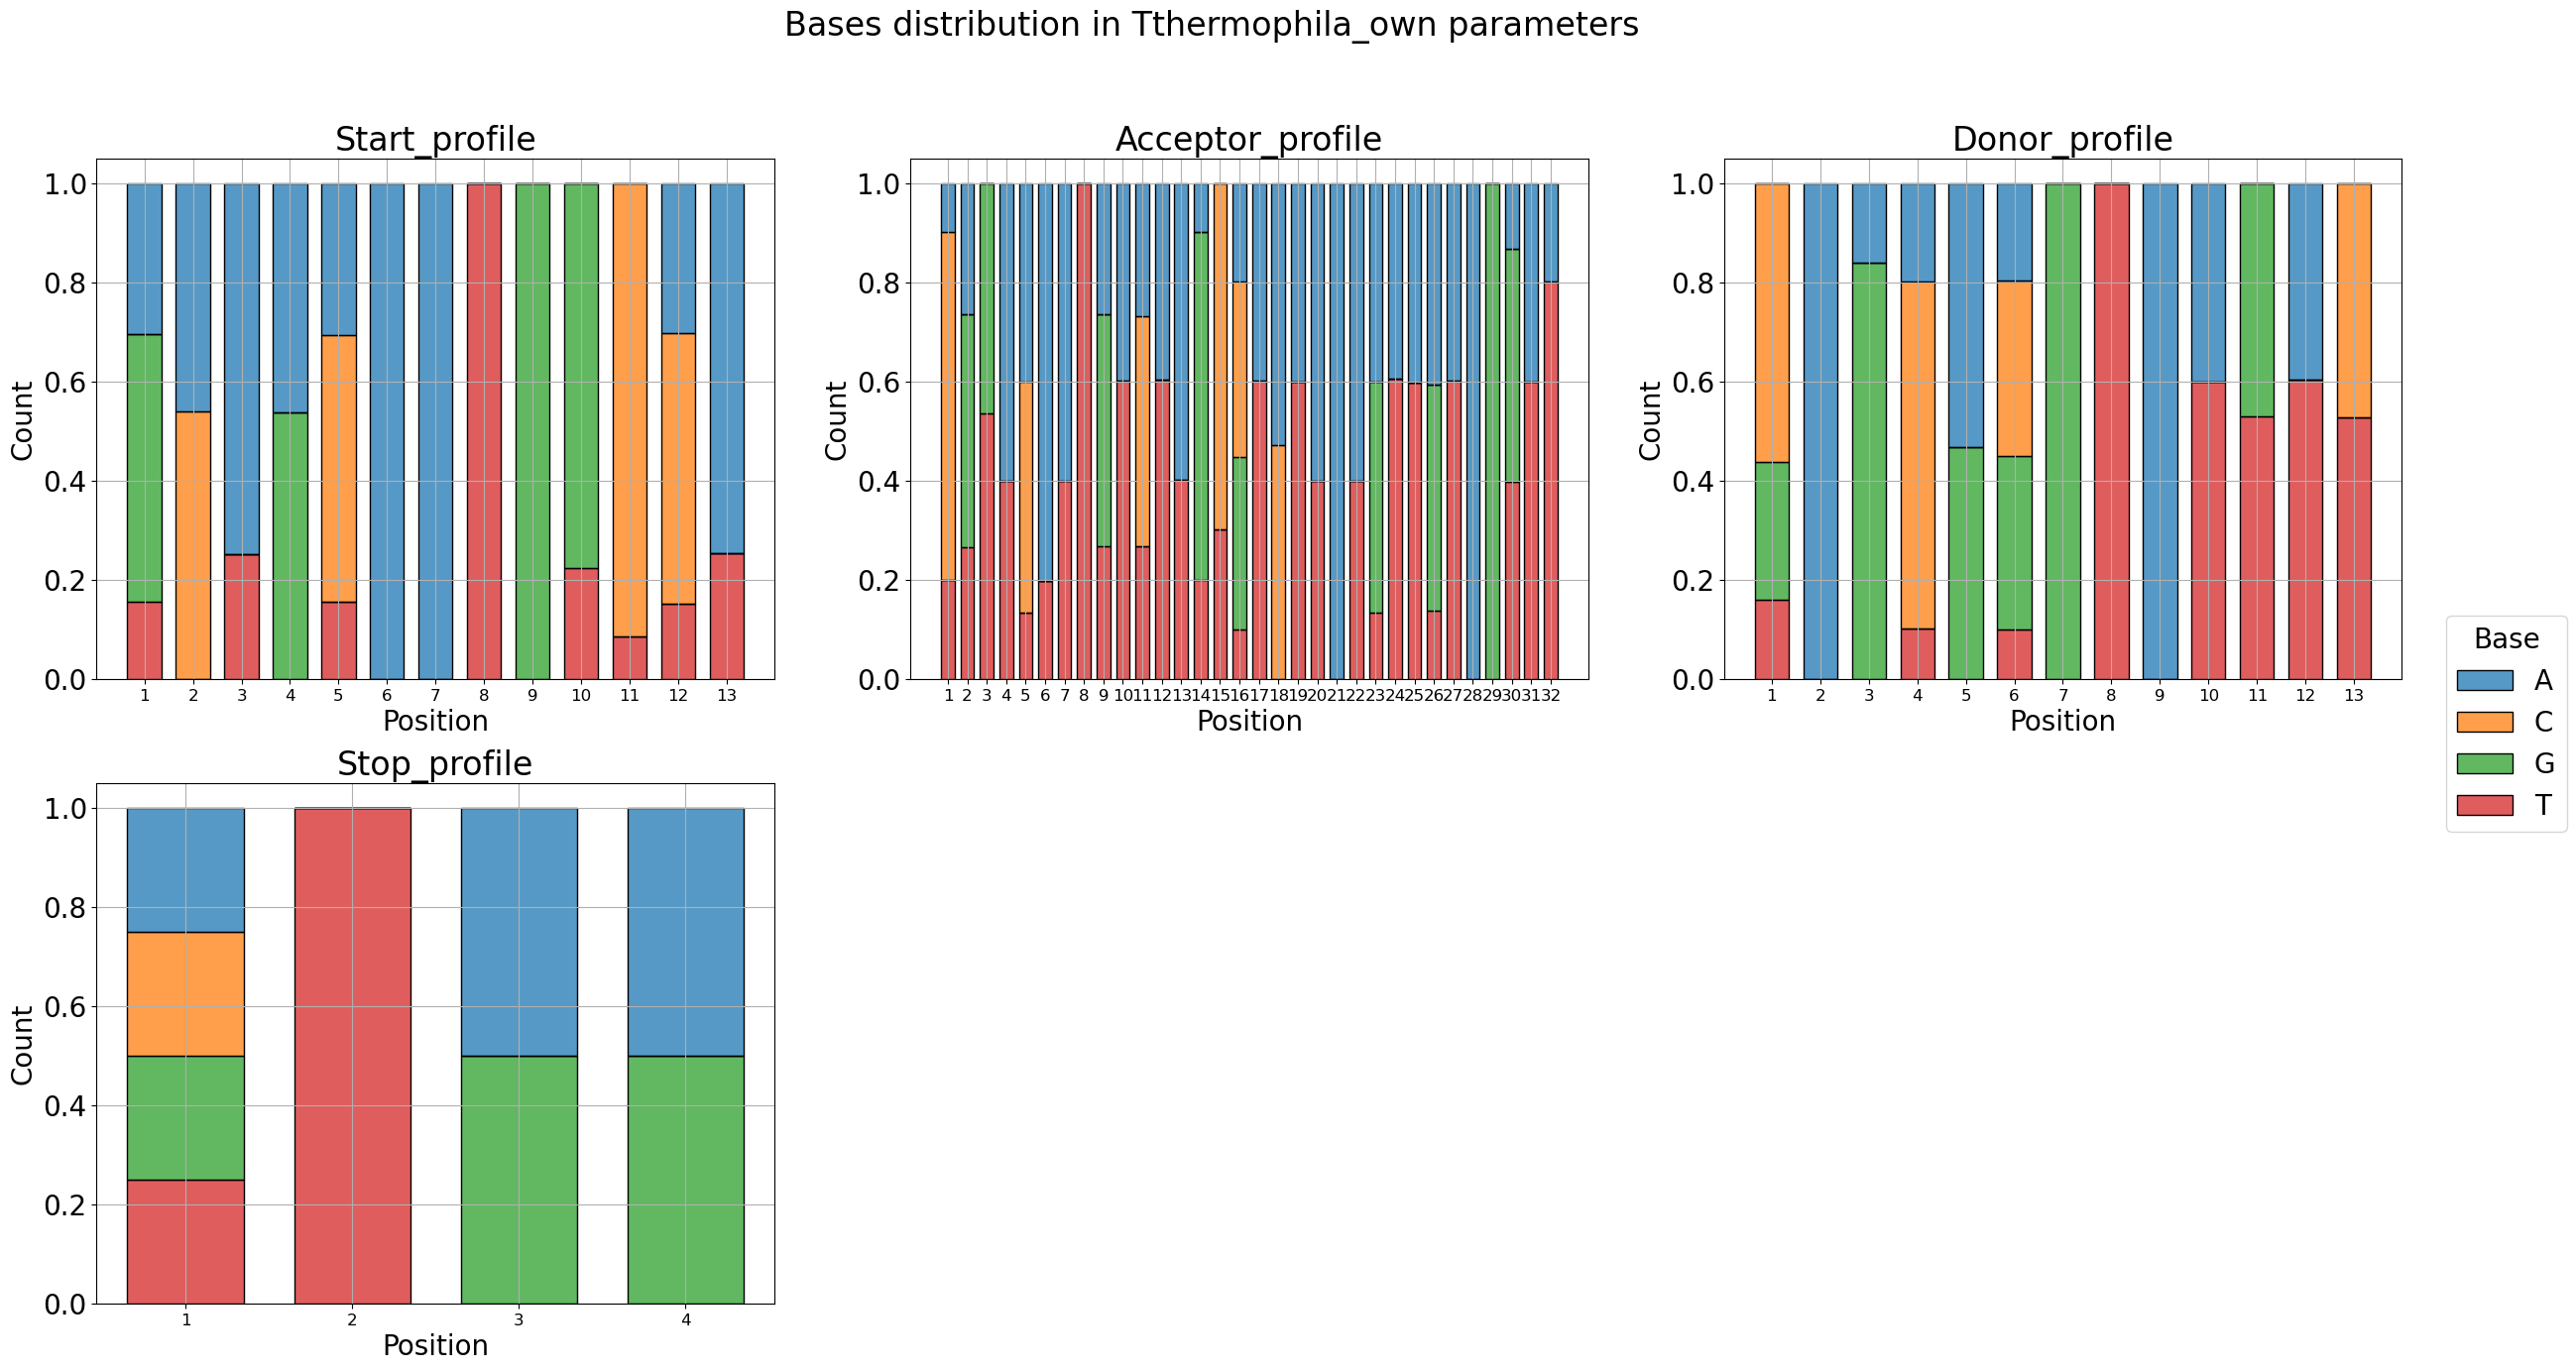

Tetrahymena_thermophila presents error: [Errno 2] No such file or directory: '../results/trainedParams/Tetrahymena_thermophila.geneid.optimized.param'
Using files:  /home/jj/Desktop/Data_science/CRG/TFM/projects/geneid-training/training_data/geneid-parameter-files/parameter_files/Tetrahymena_thermophila.5911.param
Start_profile
Stop_profile


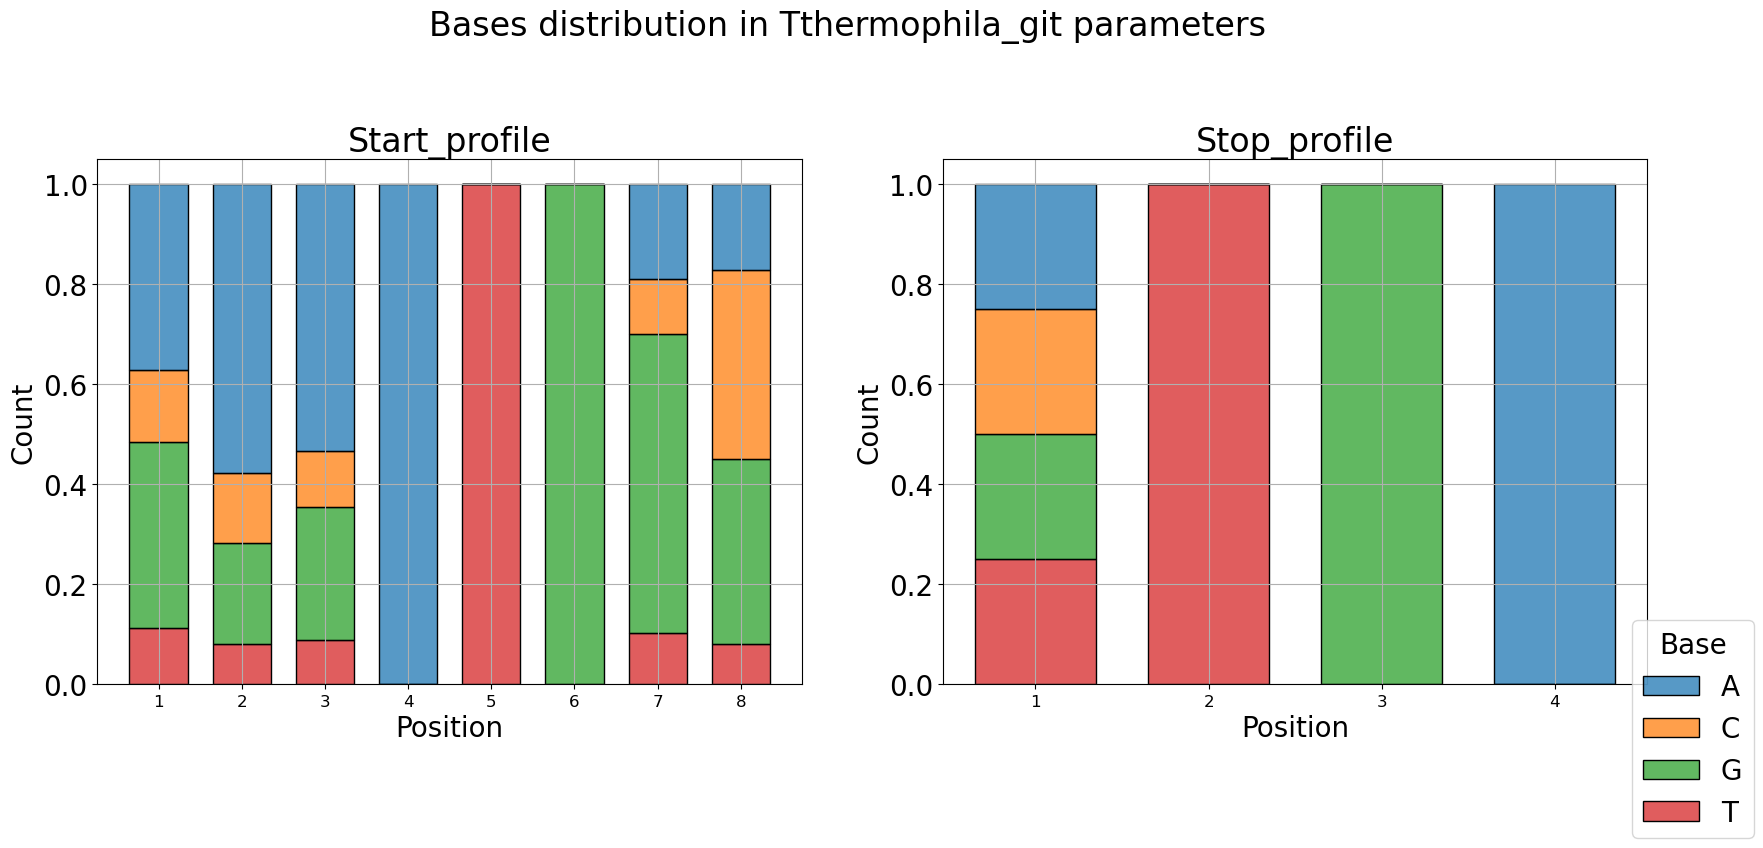

Tetrahymena_thermophila presents error: [Errno 2] No such file or directory: '../results/trainedParams/Tetrahymena_thermophila.geneid.optimized.param'


In [15]:
# Set species of interest
tr_sp=!ls $raw_data
tr_sp=["Tetrahymena_thermophila"]

for source in ["own", "git"]:
    for specie in tr_sp:
        #specie="Plasmodium_falciparum"
        #specie="Plasmodium_vivax"
        #Set source of parameters (git if pregenerated are existent)
        shortname=shortnamer(specie)

        try:
            filename=f"../results/trainedParams/{specie}"
            found_files=!realpath $filename*.optimized.param

            if source!="own": #source=="git"
                #obtain and clean file path (allows for variation after species name)
                filename=f"../training_data/geneid-parameter-files/parameter_files/{specie}"
                found_files=!realpath $filename*.param 2>/dev/null #supress error output

                if not found_files: #set up error for species with no github parameters
                    raise FileNotFoundError(f"There is no github parameters for this species")
            
            filename=found_files[0]


            print("Using files: ",filename)

            df=parse_geneid_to_dataframe(filename)

            #Plot probabilities of bases in the acceptor, stop, donor and start profiles
            plotTitle=shortname+"_"+source
            baseplots(df, specie, source, plotTitle)
            
            #Plot probabilities of kmers in probability matrices
            mk_i, mk_t=markov_merger(specie)
            statsplots(mk_t, specie, "transition", "Transition_"+shortname)
            statsplots(mk_i, specie, "individual", "Individual_"+shortname)

        except Exception as e:
            print(f"{specie} presents error: {e}")
            continue